# Stochastic Linear Bandits with context - LinUCB - A completely toy scenario 

### ***Summer School - June, 29 2026***

A demand response aggregator (DRA) aims to sell load reductions (and recently upward variations - but we let this case for another summer school) on short-term electricity markets (see [NEBCO](https://www.services-rte.com/en/learn-more-about-our-services/participate-nebef-mechanism) mechanism explanations provided by RTE for further details).

We assume it can ask intermittent load reductions to various assets:
- Electrical vehicules (EV) that switch on for charging during the night (8 pm - 7am) or mid-day (10am - 5pm) with an half-hourly load of 4kWh (domestic power socket);
- Hot water tanks that switch on almost at random throughout the day (mainly when the hot water inside cools down to a set temperature or when hot water is drawn) with an hourly load of 3kWh;
- Electric heaters that switch on when the outside temperature is below 15°C with an hourly load of  5 $\max(0, 15° - T_t)$ kWh;
- Air conditionings that switch on when the outside temperature exceed 25°C with an hourly load of 2 $\max(0, T_t - 25°)$ kWh.

Some devices can be directly controlled using hardware installed in customers' homes. For heatings and ACs, the DRA will interrupt usage for one half-hour. The customer can of course turn their heating or AC back on. For the hot water tanks, it is similar, except that it automatically turns back on if the water becomes too cold. Finally, for the EVs, let’s assume that the DRA sends a signal to the consumer (a text message), who can choose whether or not to delay charging by one half-hour. 

In order to be able to make a credible (and profitable) offer on the market, the DRA must accurately estimate the reduction it is offering, whilst seeking to maximise it (we entrust the pricing strategy to it). 

Let us assume that at each time step $t$, the DRA can propose truning off to one and only one active device $a_t$ (we may assume that there is always either a hot water tank running or an EV charging to be targeted). Then, it observes de load reduction $r_t$ (in pratice, this is done by RTE).

To model the variability in the customer response, we assume the load reduction to be perturbed by a random gaussian noise $\eta_t$. If, instead of a single device, we assume that we have a large number of active devices to which we can send requests each time, this model holds up well thanks to the law of large numbers; with the exception that the variance would depend on the device chosen $a_t$ (we will examine a more realistic, though less theoretically consistent, version of the problem later). 
We assume that the DRA does not know either the mean load of each device. However, it does know the charging time windows of EV and that heating and AC loads are proportional to temperature differences.

Let's write the problem!
 - Action set: 
 $$\mathcal{A} = \big\{(1,0,0,0)^{\mathrm{T}},(0,1,0,0)^{\mathrm{T}},(0,0,1,0)^{\mathrm{T}},(0,0,0,1)^{\mathrm{T}}\big\}\,,$$
where $(1,0,0,0)$ of EV, $(0,1,0,0)$ for heating etc.
 - Mapping context function to model EVs availability (only during charging hours) and temperature imapct of heatings and ACs. For any half-hour $hh$, temperature $T$ and device $a\in \mathcal{A}$, it return the 4-dimensional vector proportionnal:

  $$ \phi (\mathrm{hh},T,a) = (a_1 \mathbf{1}_{hh_t \in [\mathrm{charging hours}]},a_2,a_3\max(0, 15 - T),a_4\max(0, T - 25))^{\mathrm{T}}\,.$$

  - Parameter: $\theta = (2,1.5,2.5,1)^\mathrm{T}$ (mean load of each device). 

At an instant $t$, if the DRA picks action $a$, the reduction is $r_t =  \phi(hh_t,T_t,a)^{\mathrm{T}} \theta + \eta_t$ where $\eta_t \sim \mathcal{N}(0,1)$.

We will propose that it uses the LinUCB bandit algorithm to maximize the potential load reduction at each half-hour interval. This algorithm provides an estimate of the expected reward, which can then be used to build offers on the market. However, we recommend that the DRA wait until the algorithm has learned sufficiently before doing so (as RTE evaluates the reliability of DRAs).




In [126]:
import numpy as np
import pandas as pd 
import random
import matplotlib.pyplot as plt 

df_context = pd.read_csv('electrical_demand_data.csv', index_col = 'date_time')[['temperature','half_hour']]
df_context.index = pd.to_datetime(df_context.index, format='mixed')
df_context.head()

theta  = np.array([4,3,5,2])/2 # half-hourly load of each device 
sigma = 1 


In [127]:
def mapping(context, action):
    heating = max(0,15-context['temperature'])
    ac = max(0, context['temperature'] - 25)
    ev_ischarging = ((context['half_hour']<14) or 
                     (context['half_hour']>=20)*(context['half_hour']<34) or 
                     (context['half_hour']>40))*1
    return np.array([ev_ischarging,1,heating,ac])*action

In [128]:
def ucb(df_context, theta, sigma, beta, lamb = 1):
    T = len(df_context)
    d = len(theta)
    A = np.diag(np.ones(d))
    A_size = len(A)
    actions = np.zeros([T,d])
    best_actions = np.zeros([T,d])
    rewards = np.zeros(T)
    bests = np.zeros(T)
    
    phi_all = np.array([mapping(df_context.iloc[0, :], A[i, :]) for i in range(A_size)])
    best_actions[0,:] = A[np.argmax(phi_all@theta),:]

    # random choice for first iteration 
    actions[0,:] = A[random.randint(0,d-1),:]
    phi = mapping(df_context.iloc[0,:], actions[0,:])
    rewards[0] = phi@theta + random.normalvariate(0, sigma)
    V = lamb*np.diag(np.ones(d)) + phi.reshape(-1, 1) @ phi.reshape(-1, 1).T
    S = rewards[0] * phi 
    for t in range(1,T):
        solve_V = np.linalg.inv(V)
        hat_theta = solve_V@ S
        phi_all = np.array([mapping(df_context.iloc[t, :], A[i, :]) for i in range(A_size)])
        alpha_all = beta[t]*np.array([(phi_all[i,:].reshape(-1, 1).T@solve_V@phi_all[i,:].reshape(-1, 1))[0][0] for i in range(A_size)])
        ucb_all = phi_all@hat_theta + alpha_all
        best_actions[t,:] = A[np.argmax(phi_all@theta),:]
        actions[t,:] = A[np.argmax(ucb_all),:]
        phi = mapping(df_context.iloc[t,:], actions[t,:])
        rewards[t] = phi@theta + random.normalvariate()
        bests[t] = mapping(df_context.iloc[t,:], best_actions[t,:])@theta

        V = V + phi.reshape(-1, 1) @ phi.reshape(-1, 1).T
        S = S + rewards[t] * phi 
    return actions, rewards,best_actions, bests,  hat_theta, S, V

beta = 100*np.log(range(1,len(df_context)+1))
actions, rewards,best_actions, bests,  hat_theta, S, V = ucb(df_context, theta, sigma, beta, lamb = 1)

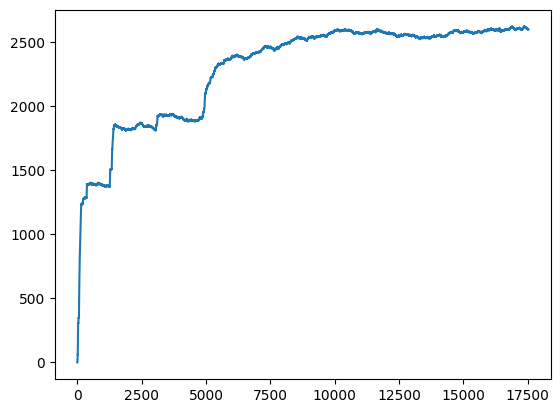

In [129]:
plt.plot(np.cumsum(bests-rewards))

In [111]:
hat_theta

array([1.61400097, 1.35321101, 1.73222036, 0.69765671])

In [112]:
theta

array([1.6 , 1.35, 1.75, 0.7 ])

In [122]:
random.normalvariate()

1.367561668731783


Some uses can be directly controlled using hardware installed in customers' homes. For heatings and ACs, the DRA will interrupt usage for one half-hour. The customer can of course turn their heating or AC back on. Let’s assume this happens with a probability of 0.3. For the hot water tanks, it is similar, except that it automatically turns back on if the water becomes too cold; let’s say this occurs with a probability of 0.1 (we could vary this probability by increasing it around 7 a.m. and 9 p.m., since this is when people typically take showers, do the dishes, etc., but let’s leave that too for a future summer school). Finally, for the EVs, let’s assume that the DRA sends a signal to the consumer (a text message), who can choose whether or not to delay charging by one half-hour, and suppose they accept with a probability of 0.8.

In order to be able to make a credible (and profitable) offer on the market, the DRA must accurately estimate the reduction it is offering, whilst seeking to maximise it (we entrust the pricing strategy to it). 

We assume that the DRA does not know either the load of each device or the customers’ acceptance probabilities for load reduction. However, it does know the charging time windows of EV and that heating and AC loads are proportional to temperature differences.

Let us assume that at each time step, the DRA can propose truning off to one and only one active device (we may assume that there is always either a hot water tank running or an EV charging to be targeted; it is easy to relax this assumption by modifying the probabilities of positive responses to the reduction).

We will propose that the DRA uses the LinUCB bandit algorithm to maximize the potential load reduction at each half-hour interval. This algorithm provides an estimate of the expected reward, which can then be used to build offers on the market. However, we recommend that the DRA wait until the algorithm has learned sufficiently before doing so (as RTE evaluates the reliability of DRAs).

Let's model the problem
 - Action set: 
 $$\mathcal{A} = \big\{(1,0,0,0)^{\mathrm{T}},(0,1,0,0)^{\mathrm{T}},(0,0,1,0)^{\mathrm{T}},(0,0,0,1)^{\mathrm{T}}\big\}\,,$$
where $(1,0,0,0)$ of EV, $(0,1,0,0)$ for heating etc.
 - Mapping context function to model EVs availability (only during charging hours) and temperature imapct of heatings and ACs. For any half-hour $hh$, temperature $T$ and device $a\in \mathcal{A}$, it return the 4-dimensional vector proportionnal:

  $$ \phi (\mathrm{hh},T,a) = (a_1 \mathbf{1}_{hh_t \in [\mathrm{charging hours}]},a_2,a_3\max(0, 15 - T),a_4\max(0, T - 25))^{\mathrm{T}}$$

  - Parameter: $L = (2,1.5,2.5,1)^\mathrm{T}$ to model the load. 
  - Vector of probabilities of positive responses: $B = (0.8, 0.9, 0.7, 0.7)^{\mathrm{T}}$

At an instant $t$, if the DRA picks action $a$, with $b_t \sim \mathcal{B}(a^\mathrm{T}B)$, the reduction is $r_t = b_t \times \phi(hh_t,T_t,a)^{\mathrm{T}} L$. 

We introduce the 4-dimension vector $\theta$, with $\theta_j = L_j*B_j$. Thus, at an instant $t$, the reduction r_t satisfies:

$$\mathbb{E}\big[ r_t | a_t = a \big] = \phi(hh_t,T_t,a)^{\mathrm{T}}\theta\,,$$


so we can use Lin-UCB!

In [ ]:
B = np.array([0.8, 0.9, 0.7, 0.7])
#B = np.array([1, 1, 1, 1])

def ucb(df_context, L, B, beta, lamb = 1):
    T = len(df_context)
    theta = L*B
    d = len(theta)
    A = np.diag(np.ones(d))
    A_size = len(A)
    actions = np.zeros([T,d])
    best_actions = np.zeros([T,d])
    rewards = np.zeros(T)
    bests = np.zeros(T)

    phi_all = np.array([mapping(df_context.iloc[0, :], A[i, :]) for i in range(A_size)])
    best_actions[0,:] = A[np.argmax(phi_all@theta),:]
    # random choice for first iteration 
    actions[0,:] = A[random.randint(0,d-1),:]
    phi = mapping(df_context.iloc[0,:], actions[0,:])
    p = np.random.binomial(n=1, p=B)@actions[0,:]
    rewards[0] = np.random.binomial(n=1, p=B)@actions[0,:]*phi@L
    V = lamb*np.diag(np.ones(d)) + phi.reshape(-1, 1) @ phi.reshape(-1, 1).T
    S = rewards[0] * phi 
    for t in range(1,T):
        solve_V = np.linalg.inv(V)
        hat_theta = solve_V@ S
        phi_all = np.array([mapping(df_context.iloc[t, :], A[i, :]) for i in range(A_size)])
        alpha_all = beta[t]*np.array([(phi_all[i,:].reshape(-1, 1).T@solve_V@phi_all[i,:].reshape(-1, 1))[0][0] for i in range(A_size)])
        ucb_all = phi_all@hat_theta + alpha_all
        best_actions[t,:] = A[np.argmax(phi_all@theta),:]
        actions[t,:] = A[np.argmax(ucb_all),:]
        phi = mapping(df_context.iloc[t,:], actions[t,:])
        rewards[t] = np.random.binomial(n=1, p=B)@actions[t,:]*phi@L
        bests[t] = mapping(df_context.iloc[t,:], best_actions[t,:])@theta

        V = V + phi.reshape(-1, 1) @ phi.reshape(-1, 1).T
        S = S + rewards[t] * phi 
    return actions, rewards,best_actions, bests, theta, hat_theta, S, V

beta = 10*np.log(range(1,len(df_context)+1))
actions, rewards,best_actions, bests,  theta, hat_theta, S, V = ucb(df_context, L,B, beta, lamb = 1)